# Chapter 5 — Learning Multiple Weights at a Time: Generalizing Gradient Descent

**Grokking Deep Learning — Andrew W. Trask**


Notebook ini mengikuti struktur dan contoh numerik *Chapter 5*. Penjelasan menggunakan Bahasa Indonesia, sedangkan istilah teknis dan kode mempertahankan konteks buku.

## Learning Objectives

Chapter ini memperluas gradient descent dari satu weight menjadi banyak weight.

Fokus utama:
- **Multiple inputs**
- Menghitung `weight_deltas` untuk setiap input
- Melihat pengaruh input terhadap besar perubahan weight
- **Freezing one weight**
- **Multiple outputs**
- **Multiple inputs and outputs**
- Memahami weight sebagai representasi korelasi
- Memahami **dot product** sebagai ukuran kemiripan sederhana

## Chapter Roadmap

**Single weight**

`input → weight → prediction → error → weight update`

**Multiple weights**

`input vector → weights vector → weighted sum → prediction → error → multiple weight updates`

Ide pentingnya: mekanisme gradient descent yang dipelajari pada Chapter 4 tidak berubah. Mekanisme yang sama diterapkan pada setiap weight.

## 1. Gradient Descent Learning with Multiple Inputs

Buku menggunakan tiga input:
- `toes`
- `wlrec` — win/loss record
- `nfans` — number of fans

dengan initial weights:

\[
weights=[0.1,\ 0.2,\ -0.1]
\]

Prediction dihitung sebagai weighted sum.

In [ ]:
import numpy as np
def w_sum(a, b):
    assert(len(a) == len(b))
    output = 0
    for i in range(len(a)):
        output += (a[i] * b[i])
    return output

def neural_network(input, weights):
    pred = w_sum(input, weights)
    return pred

weights = [0.1, 0.2, -0.1]

toes = [8.5, 9.5, 9.9, 9.0]
wlrec = [0.65, 0.8, 0.8, 0.9]
nfans = [1.2, 1.3, 0.5, 1.0]
win_or_lose_binary = [1, 1, 0, 1]

true = win_or_lose_binary[0]
input = [toes[0], wlrec[0], nfans[0]]

pred = neural_network(input, weights)
error = (pred - true) ** 2
delta = pred - true

print("Input:", input)
print("Weights:", weights)
print("Prediction:", pred)
print("Error:", error)
print("Delta:", delta)

Input: [8.5, 0.65, 1.2]
Weights: [0.1, 0.2, -0.1]
Prediction: 0.8600000000000001
Error: 0.01959999999999997
Delta: -0.1399999999999999


### Nilai awal yang penting

Untuk contoh pertama:

\[
8.5(0.1)+0.65(0.2)+1.2(-0.1)=0.86
\]

Karena target `true = 1`, maka:

\[
delta=0.86-1=-0.14
\]

Nilai `delta` yang sama akan digunakan untuk menghitung perubahan pada ketiga weight.

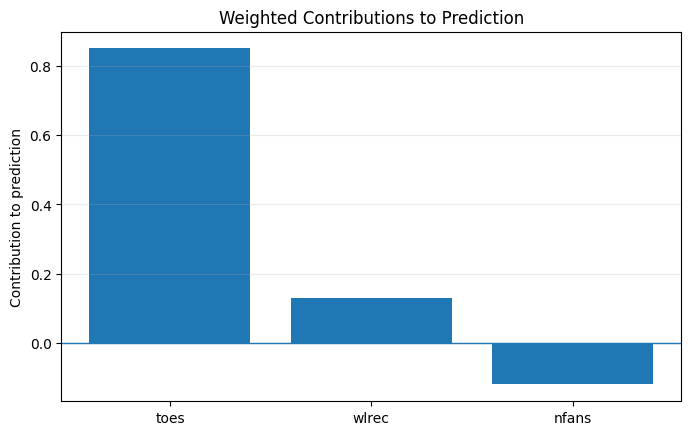

Contributions: [ 0.85  0.13 -0.12]
Sum: 0.8600000000000001


In [ ]:
inputs = np.array(input)
weights_np = np.array(weights)
contributions = inputs * weights_np

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4.8))
plt.bar(["toes", "wlrec", "nfans"], contributions)
plt.axhline(0, linewidth=1)
plt.ylabel("Contribution to prediction")
plt.title("Weighted Contributions to Prediction")
plt.grid(axis="y", alpha=0.25)
plt.show()

print("Contributions:", contributions)
print("Sum:", contributions.sum())

## 2. Calculating Each `weight_delta`

Pada multiple inputs, setiap weight memiliki input yang berbeda tetapi menggunakan `delta` output yang sama.

\[
weight\_delta_i=input_i	imes delta
\]

Dengan `delta = -0.14`:

- `8.5 × -0.14 = -1.19`
- `0.65 × -0.14 = -0.091`
- `1.2 × -0.14 = -0.168`

Ini adalah angka yang ditunjukkan dalam contoh buku.

In [ ]:
def ele_mul(number, vector):
    output = [0, 0, 0]
    assert(len(output) == len(vector))
    for i in range(len(vector)):
        output[i] = number * vector[i]
    return output

weight_deltas = ele_mul(delta, input)

print("Delta:", delta)
print("Weight deltas:", weight_deltas)

Delta: -0.1399999999999999
Weight deltas: [-1.189999999999999, -0.09099999999999994, -0.16799999999999987]


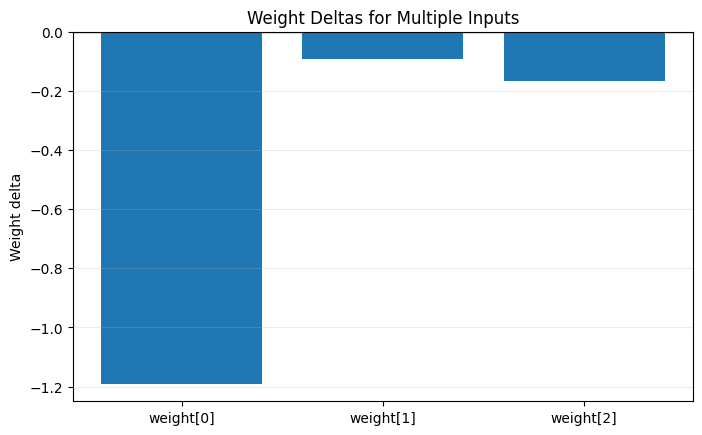

In [ ]:
plt.figure(figsize=(8, 4.8))
plt.bar(["weight[0]", "weight[1]", "weight[2]"], weight_deltas)
plt.axhline(0, linewidth=1)
plt.ylabel("Weight delta")
plt.title("Weight Deltas for Multiple Inputs")
plt.grid(axis="y", alpha=0.25)
plt.show()

### Mengapa `weight_delta` berbeda?

Ketiga weight menerima `delta` yang sama, tetapi setiap weight dikalikan dengan input yang berbeda.

Jadi input yang lebih besar menghasilkan perubahan weight yang lebih besar. Inilah alasan weight pertama pada contoh buku berubah paling banyak: input `toes = 8.5` jauh lebih besar daripada `wlrec = 0.65` dan `nfans = 1.2`.

Old weights: [0.1, 0.2, -0.1]
New weights: [0.1119, 0.20091, -0.09832]


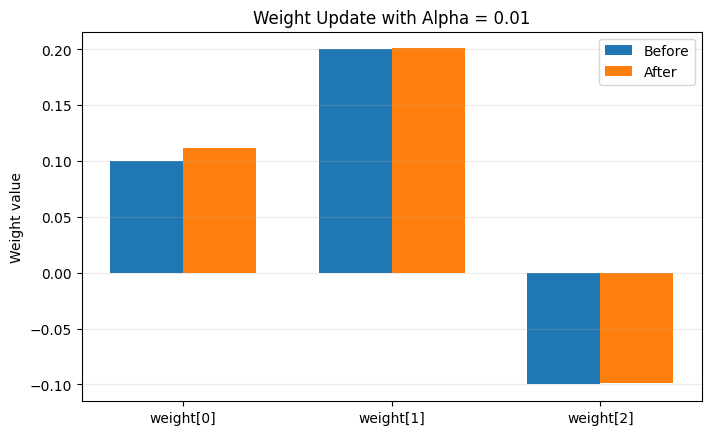

In [ ]:
alpha = 0.01
new_weights = np.array(weights) - alpha * np.array(weight_deltas)

print("Old weights:", weights)
print("New weights:", new_weights.tolist())

plt.figure(figsize=(8, 4.8))
x = np.arange(3)
width = 0.35
plt.bar(x - width/2, weights, width, label="Before")
plt.bar(x + width/2, new_weights, width, label="After")
plt.xticks(x, ["weight[0]", "weight[1]", "weight[2]"])
plt.ylabel("Weight value")
plt.title("Weight Update with Alpha = 0.01")
plt.legend()
plt.grid(axis="y", alpha=0.25)
plt.show()

## 3. Watching Several Steps of Learning

Buku kemudian menjalankan training selama tiga iteration dengan:

- `alpha = 0.01`
- `weights = [0.1, 0.2, -0.1]`
- input pertama `[8.5, 0.65, 1.2]`

Contoh buku menunjukkan prediction bergerak dari `0.86` menuju `0.991` dan error semakin kecil.

In [ ]:
weights = [0.1, 0.2, -0.1]
alpha = 0.01
history = []

for iteration in range(3):
    pred = neural_network(input, weights)
    error = (pred - true) ** 2
    delta = pred - true
    weight_deltas = ele_mul(delta, input)

    history.append([iteration + 1, pred, error, *weights, *weight_deltas])

    for i in range(len(weights)):
        weights[i] -= alpha * weight_deltas[i]

for row in history:
    print(
        f"Iteration {int(row[0])}: "
        f"Pred={row[1]:.6f}, Error={row[2]:.6f}, "
        f"Weights={[round(v, 6) for v in row[3:6]]}, "
        f"Weight deltas={[round(v, 6) for v in row[6:9]]}"
    )

Iteration 1: Pred=0.860000, Error=0.019600, Weights=[0.1, 0.2, -0.1], Weight deltas=[-1.19, -0.091, -0.168]
Iteration 2: Pred=0.963757, Error=0.001314, Weights=[0.1119, 0.20091, -0.09832], Weight deltas=[-0.308061, -0.023558, -0.043491]
Iteration 3: Pred=0.990618, Error=0.000088, Weights=[0.114981, 0.201146, -0.097885], Weight deltas=[-0.079749, -0.006098, -0.011259]


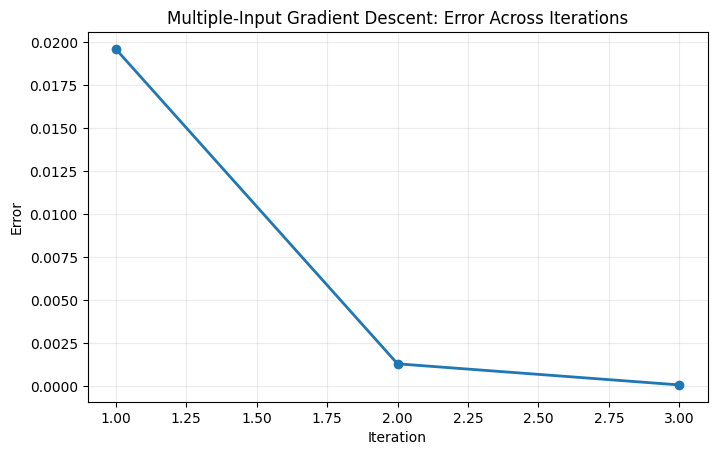

In [ ]:
h = np.array(history)

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.plot(h[:, 0], h[:, 2], marker="o", linewidth=2)
ax.set_xlabel("Iteration")
ax.set_ylabel("Error")
ax.set_title("Multiple-Input Gradient Descent: Error Across Iterations")
ax.grid(alpha=0.25)
plt.show()

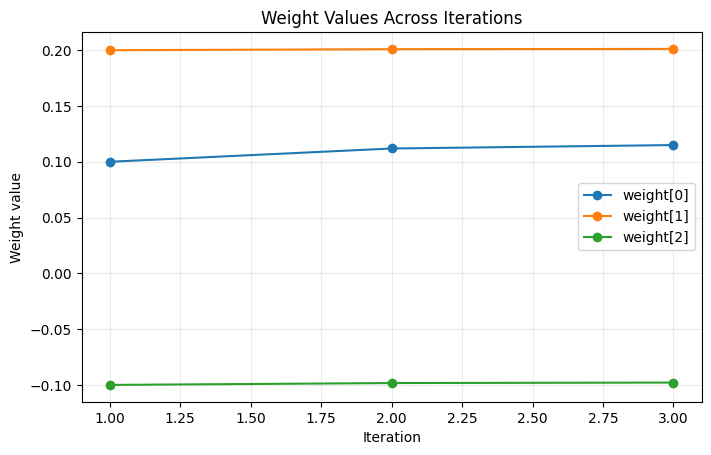

In [ ]:
plt.figure(figsize=(8, 4.8))
plt.plot(h[:, 0], h[:, 3], marker="o", label="weight[0]")
plt.plot(h[:, 0], h[:, 4], marker="o", label="weight[1]")
plt.plot(h[:, 0], h[:, 5], marker="o", label="weight[2]")
plt.xlabel("Iteration")
plt.ylabel("Weight value")
plt.title("Weight Values Across Iterations")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

## 4. Freezing One Weight

Buku kemudian melakukan eksperimen dengan **weight pertama dibekukan**:

```python
weight_deltas[0] = 0
```

Artinya weight pertama tidak pernah di-update, sementara weight kedua dan ketiga tetap belajar.

Hal penting yang ditunjukkan buku: error tetap dapat mencapai titik minimum melalui weight lain. Namun jika network sudah mencapai `error = 0`, weight yang dibekukan tidak akan mendapat kesempatan untuk belajar karena `weight_delta` menjadi 0.

In [ ]:
def train_with_frozen_first_weight(iterations=3):
    weights = [0.1, 0.2, -0.1]
    alpha = 0.3
    records = []

    for iteration in range(iterations):
        pred = neural_network(input, weights)
        error = (pred - true) ** 2
        delta = pred - true
        weight_deltas = ele_mul(delta, input)

        weight_deltas[0] = 0

        records.append([iteration + 1, pred, error, *weights, *weight_deltas])

        for i in range(len(weights)):
            weights[i] -= alpha * weight_deltas[i]

    return np.array(records)

frozen_history = train_with_frozen_first_weight()

for row in frozen_history:
    print(
        f"Iteration {int(row[0])}: "
        f"Pred={row[1]:.6f}, Error={row[2]:.6f}, "
        f"Weights={[round(v, 6) for v in row[3:6]]}"
    )

Iteration 1: Pred=0.860000, Error=0.019600, Weights=[np.float64(0.1), np.float64(0.2), np.float64(-0.1)]
Iteration 2: Pred=0.938225, Error=0.003816, Weights=[np.float64(0.1), np.float64(0.2273), np.float64(-0.0496)]
Iteration 3: Pred=0.972742, Error=0.000743, Weights=[np.float64(0.1), np.float64(0.239346), np.float64(-0.027361)]


## 5. Multiple Outputs

Sekarang satu input digunakan untuk menghasilkan **tiga prediction**.

Buku menggunakan:
- `hurt`
- `win`
- `sad`

dengan weights:

\[
[0.3,\ 0.2,\ 0.9]
\]

Input yang digunakan adalah `wlrec[0] = 0.65`.

In [ ]:
def scalar_ele_mul(number, vector):
    output = [0, 0, 0]
    assert(len(output) == len(vector))
    for i in range(len(vector)):
        output[i] = number * vector[i]
    return output

weights = [0.3, 0.2, 0.9]

wlrec = [0.65, 1.0, 1.0, 0.9]
hurt = [0.1, 0.0, 0.0, 0.1]
win = [1, 1, 0, 1]
sad = [0.1, 0.0, 0.1, 0.2]

input_single = wlrec[0]
true_outputs = [hurt[0], win[0], sad[0]]

pred_outputs = scalar_ele_mul(input_single, weights)
errors = [(pred_outputs[i] - true_outputs[i]) ** 2 for i in range(3)]
deltas = [pred_outputs[i] - true_outputs[i] for i in range(3)]

print("Predictions:", pred_outputs)
print("True:", true_outputs)
print("Errors:", errors)
print("Deltas:", deltas)

Predictions: [0.195, 0.13, 0.5850000000000001]
True: [0.1, 1, 0.1]
Errors: [0.009025, 0.7569, 0.2352250000000001]
Deltas: [0.095, -0.87, 0.4850000000000001]


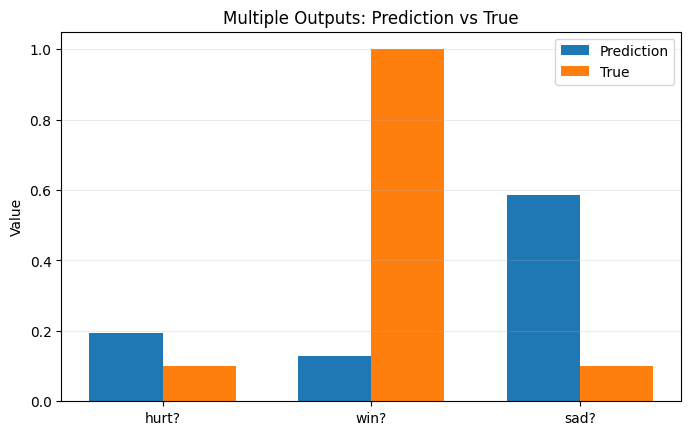

In [ ]:
plt.figure(figsize=(8, 4.8))
x = np.arange(3)
width = 0.35
plt.bar(x - width/2, pred_outputs, width, label="Prediction")
plt.bar(x + width/2, true_outputs, width, label="True")
plt.xticks(x, ["hurt?", "win?", "sad?"])
plt.ylabel("Value")
plt.title("Multiple Outputs: Prediction vs True")
plt.legend()
plt.grid(axis="y", alpha=0.25)
plt.show()

Setiap output memiliki `delta` sendiri. Namun karena ketiganya berasal dari satu input yang sama, input tersebut dikalikan dengan masing-masing delta untuk menghasilkan `weight_delta`.

Ini menunjukkan bahwa mekanisme gradient descent tetap sama meskipun jumlah output bertambah.

## 6. Multiple Inputs and Multiple Outputs

Buku kemudian menggabungkan keduanya. Weight menjadi matrix:

\[
weights=
egin{bmatrix}
0.1 & 0.1 & -0.3\
0.1 & 0.2 & 0.0\
0.0 & 1.3 & 0.1
\end{bmatrix}
\]

Tiga input menghasilkan tiga output melalui vector-matrix multiplication.

In [ ]:
weights_matrix = [
    [0.1, 0.1, -0.3],
    [0.1, 0.2, 0.0],
    [0.0, 1.3, 0.1]
]

def vect_mat_mul(vect, matrix):
    assert(len(vect) == len(matrix))
    output = [0, 0, 0]
    for i in range(len(vect)):
        output[i] = w_sum(vect, matrix[i])
    return output

def neural_network_multi(input, weights):
    pred = vect_mat_mul(input, weights)
    return pred

multi_input = [8.5, 0.65, 1.2]
multi_pred = neural_network_multi(multi_input, weights_matrix)

print("Input:", multi_input)
print("Predictions:", multi_pred)

Input: [8.5, 0.65, 1.2]
Predictions: [0.555, 0.9800000000000001, 0.9650000000000001]


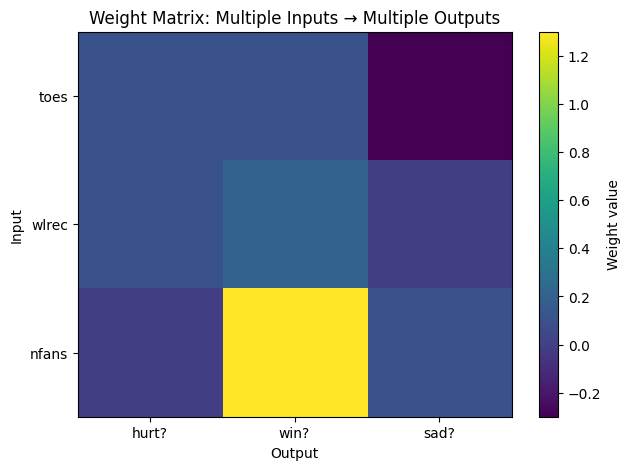

In [ ]:
plt.figure(figsize=(7, 5))
plt.imshow(np.array(weights_matrix), aspect="auto")
plt.colorbar(label="Weight value")
plt.xticks([0, 1, 2], ["hurt?", "win?", "sad?"])
plt.yticks([0, 1, 2], ["toes", "wlrec", "nfans"])
plt.xlabel("Output")
plt.ylabel("Input")
plt.title("Weight Matrix: Multiple Inputs → Multiple Outputs")
plt.show()

### Membaca weight matrix

Setiap baris merepresentasikan satu input dan setiap kolom merepresentasikan satu output.

Jadi matrix tersebut menyimpan banyak hubungan sekaligus:

**3 input × 3 output = 9 weights.**

Ini merupakan generalisasi langsung dari konsep weighted sum pada chapter sebelumnya.

## 7. What Do These Weights Learn?

Buku menjelaskan bahwa weight dapat dipahami sebagai representasi hubungan atau **correlation** antara input dan output.

Weight besar dan positif menunjukkan hubungan positif yang kuat dalam konteks model. Weight negatif menunjukkan hubungan berlawanan. Namun arti weight selalu bergantung pada data dan arsitektur yang digunakan.

## 8. Visualizing Weight Values

Untuk image classifier, setiap output node dapat memiliki weight untuk setiap pixel. Buku memberi contoh bahwa sebuah digit seperti `2` dapat memiliki **784 input weights** karena gambar MNIST berukuran 28×28.

Jika weight tersebut dibentuk kembali menjadi ukuran gambar, kita dapat melihat area pixel yang memiliki korelasi tinggi atau negatif terhadap output tertentu.

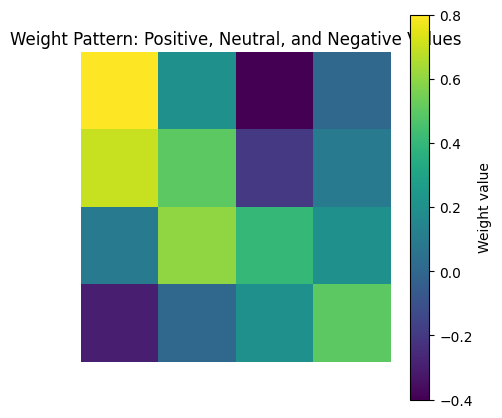

In [ ]:
# Contoh konseptual berbasis ukuran MNIST yang dibahas buku:
# 28 x 28 = 784 weights untuk satu output node.

weight_example = np.array([
    [0.8, 0.2, -0.4, 0.0],
    [0.7, 0.5, -0.2, 0.1],
    [0.1, 0.6,  0.4, 0.2],
    [-0.3, 0.0, 0.2, 0.5]
])

plt.figure(figsize=(5, 5))
plt.imshow(weight_example, aspect="equal")
plt.colorbar(label="Weight value")
plt.title("Weight Pattern: Positive, Neutral, and Negative Values")
plt.axis("off")
plt.show()

**Catatan akurasi:** visual di atas bukan hasil training MNIST dari buku. Ini hanya menunjukkan **bentuk representasi weight sebagai image** yang dijelaskan pada bagian *Visualizing weight values*. Angka dibuat sebagai contoh visual, sehingga tidak boleh dibaca sebagai weight hasil training buku.

## 9. Visualizing Dot Products

Buku mengulang konsep dot product:

\[
dot(a,b)=\sum_i a_i b_i
\]

Contoh:

\[
a=[0,1,0,1]
\]

\[
b=[1,0,1,0]
\]

Elementwise multiplication menghasilkan `[0,0,0,0]`, sehingga score = `0`.

Buku kemudian menunjukkan bahwa vector yang memiliki overlap lebih besar menghasilkan dot product yang lebih tinggi. Karena itu dot product dapat digunakan sebagai **ukuran kemiripan sederhana**.

a · b = 0
c · d = 0.5


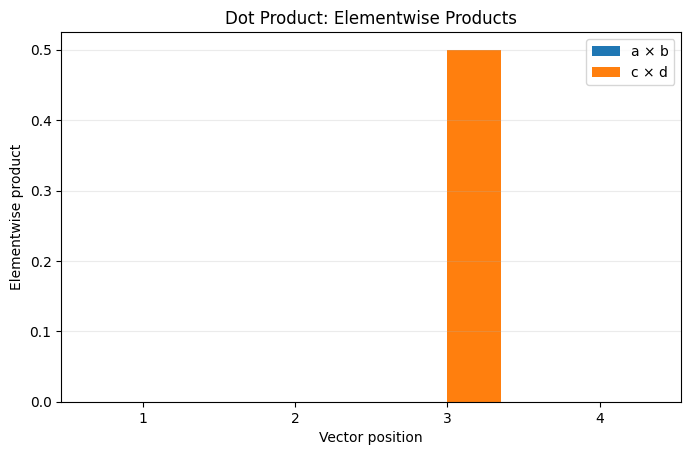

In [ ]:
a = np.array([0, 1, 0, 1])
b = np.array([1, 0, 1, 0])

c = np.array([0, 1, 1, 0])
d = np.array([0.5, 0, 0.5, 0])

print("a · b =", np.dot(a, b))
print("c · d =", np.dot(c, d))

products_ab = a * b
products_cd = c * d

plt.figure(figsize=(8, 4.8))
x = np.arange(4)
width = 0.35
plt.bar(x - width/2, products_ab, width, label="a × b")
plt.bar(x + width/2, products_cd, width, label="c × d")
plt.xticks(x, ["1", "2", "3", "4"])
plt.xlabel("Vector position")
plt.ylabel("Elementwise product")
plt.title("Dot Product: Elementwise Products")
plt.legend()
plt.grid(axis="y", alpha=0.25)
plt.show()

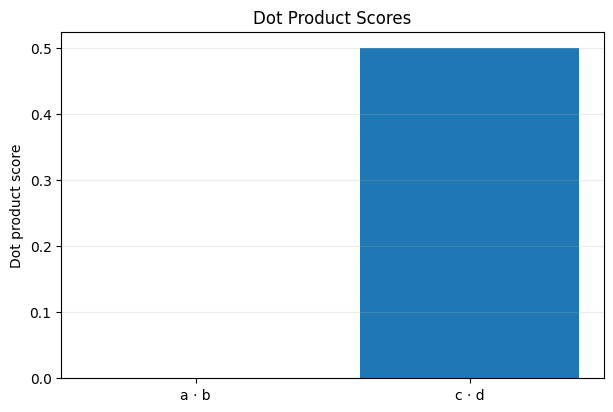

In [ ]:
similarity_scores = [np.dot(a, b), np.dot(c, d)]
plt.figure(figsize=(7, 4.5))
plt.bar(["a · b", "c · d"], similarity_scores)
plt.ylabel("Dot product score")
plt.title("Dot Product Scores")
plt.grid(axis="y", alpha=0.25)
plt.show()

### Interpretasi

- `a · b = 0` karena kedua vector tidak memiliki overlap pada posisi yang sama.
- `c · d = 0.5` karena terdapat overlap positif pada posisi yang sama.

Buku menggunakan contoh ini untuk membangun intuisi bahwa dot product yang lebih tinggi dapat menunjukkan vector yang lebih mirip.

## Concept Check

| Konsep | Inti pemahaman |
|---|---|
| Multiple inputs | Satu prediction dibentuk dari beberapa input dan weight |
| `weight_delta` | `input × delta` untuk setiap weight |
| Multiple outputs | Satu input dapat menghasilkan beberapa prediction |
| Multiple inputs + outputs | Weight menjadi matrix |
| Frozen weight | Weight tertentu tidak di-update |
| Weight values | Dapat digunakan untuk melihat hubungan/correlation yang dipelajari |
| Dot product | Penjumlahan hasil perkalian elemen yang berpasangan |
| Gradient descent | Tetap menjadi mekanisme learning yang sama |

## Key Takeaways

1. Gradient descent dapat diperluas dari satu weight ke banyak weight.
2. Setiap weight mendapatkan `weight_delta` berdasarkan input yang terhubung dengannya.
3. Input yang lebih besar dapat menghasilkan update weight yang lebih besar.
4. Satu input dapat menghasilkan banyak output dengan menggunakan beberapa weight.
5. Multiple inputs dan multiple outputs dapat direpresentasikan sebagai weight matrix.
6. Weight dapat memberikan gambaran tentang correlation yang dipelajari network.
7. Dot product memberikan intuisi tentang kemiripan antara input dan weight.
8. Kesimpulan utama buku: **gradient descent adalah general learning algorithm** yang dapat diterapkan pada berbagai arsitektur selama error dan delta dapat dihitung.

## Chapter Summary

Chapter 5 memperluas gradient descent menjadi mekanisme yang dapat menangani **multiple weights, multiple inputs, dan multiple outputs**.

Alurnya tetap:

**Predict → Compare → Calculate delta → Calculate weight_deltas → Update weights**

Perbedaannya adalah proses tersebut sekarang diterapkan pada banyak hubungan sekaligus.

Chapter berikutnya menggunakan konsep ini untuk membangun **deep neural network** dan memperkenalkan **backpropagation**.

## Reference

Trask, A. W. *Grokking Deep Learning*. Manning Publications.

**Source basis:** Chapter 5, *Learning Multiple Weights at a Time: Generalizing Gradient Descent*, termasuk bagian multiple inputs, freezing one weight, multiple outputs, multiple inputs and outputs, visualizing weight values, dan visualizing dot products.